In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torchinfo
import torchvision.transforms.functional as VF
from torch import nn
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from tqdm import tqdm
from torchlake.common.utils.image import ycbcr_transform, ycbcr_inverse_transform

from torchlake.common.controller.evaluator import RegressionEvaluator
from torchlake.common.controller.weight_manager import WeightManager
from torchlake.common.datasets.images import ImageDataset
from torchlake.common.utils.convert import img_tensor_to_np
from torchlake.common.utils.plot import plot_grids
from torchlake.common.controller.trainer import RegressionTrainer
from torchlake.super_resolution.models.vdsr import VDSR

# Setting

In [2]:
PATCH_SIZE = 33
# PADDING = (33-21)//2
STRIDE = 14
# IMAGE_SIZE = 336
BATCH_SIZE = 128 # full image => 16 worse

In [3]:
DEVICE = torch.device("cuda:0")

In [4]:
artifact_path = Path("../../artifacts/vdsr")
artifact_path.mkdir(exist_ok=True)

data_path = Path("../../data/srcnn/Train/*.bmp")
# data_path = Path("../../data/VOCdevkit/VOC2012/JPEGImages/*")
degrade_patch_path = Path("../../data/srcnn/x")
degrade_patch_path.mkdir(exist_ok=True)
clear_patch_path = Path("../../data/srcnn/y")
clear_patch_path.mkdir(exist_ok=True)
patch_path = Path("../../data/srcnn")

# Data

In [5]:
SCALE_FACTOR = 2

In [ ]:
preprocess = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

In [ ]:
train_dataset = ImageDataset(
    data_path.as_posix(),
    transform=preprocess,
)

In [8]:
print(train_dataset[0].shape)

torch.Size([3, 176, 197])


In [ ]:
patch_extractor = nn.Unfold(PATCH_SIZE, stride=STRIDE)

def collate_fn(batch):
    xs, ys = [], []
    for x in batch:
        x = x.unsqueeze(0)
        
        if x.size(1) == 1:
            x = x.repeat(1, 3, 1, 1)
        
        # rgb -> ycbcr
        x = ycbcr_transform(x)
            
        x = x[:, 0:1, :, :]

        # mod crop
        h, w = x.shape[-2:]
        x = VF.crop(x, 0, 0, h - h % SCALE_FACTOR, w - w % SCALE_FACTOR)
        h, w = x.shape[-2:]

        # degradation
        y = F.interpolate(x, size=(h // SCALE_FACTOR, w // SCALE_FACTOR), mode="bicubic")
        y = F.interpolate(y, size=(h, w), mode="bicubic")
        
        # patch
        x = patch_extractor(x).permute(0, 2, 1).reshape(-1, 1, PATCH_SIZE, PATCH_SIZE)
        y = patch_extractor(y).permute(0, 2, 1).reshape(-1, 1, PATCH_SIZE, PATCH_SIZE)
        
        xs.append(y) # .clamp(0, 1) worse model, enhance bicubic
        ys.append(x)
        
    return torch.cat(xs), torch.cat(ys)

In [ ]:
# uncomment to create patches

# import cv2
# import numpy as np

# patch_loader = DataLoader(
#     train_dataset,
#     batch_size=BATCH_SIZE,
#     collate_fn=collate_fn,
#     shuffle=False,
#     drop_last=False,
# )

# i = 0
# for x, y in tqdm(patch_loader):
#     for patch_x, patch_y in zip(img_tensor_to_np(x, scale=255, output_type=np.uint8), img_tensor_to_np(y, scale=255, output_type=np.uint8)):
#         cv2.imwrite(degrade_patch_path / f"{i}.jpg", patch_x)
#         cv2.imwrite(clear_patch_path / f"{i}.jpg", patch_y)
#         i+=1

In [11]:
from torchlake.common.utils.image import load_image

class SRCNNDataset(torch.utils.data.Dataset):
    def __init__(self, root: str | Path, transform=None):
        self.root = Path(root)
        self.paths = tuple(self.root.glob("x/*.jpg"))
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        x = load_image(self.paths[idx], is_tensor=True)
        y = load_image(self.paths[idx].as_posix().replace("x", "y"), is_tensor=True)
        
        if self.transform:
            x = self.transform(x)

        return x, y

In [12]:
train_dataset = SRCNNDataset(patch_path)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    drop_last=True,
)

In [14]:
for x, y in train_loader:
    print(x.shape, y.shape)
    break

torch.Size([128, 1, 33, 33]) torch.Size([128, 1, 33, 33])


# model

In [15]:
model = VDSR(
    input_channel=1,
    hidden_dim = 64,
    num_blocks = 20,
).to(DEVICE)

In [16]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
VDSR                                     --
├─ResBlock: 1-1                          --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  640
│    │    └─ReLU: 3-2                    --
│    │    └─Conv2d: 3-3                  36,928
│    │    └─ReLU: 3-4                    --
│    │    └─Conv2d: 3-5                  36,928
│    │    └─ReLU: 3-6                    --
│    │    └─Conv2d: 3-7                  36,928
│    │    └─ReLU: 3-8                    --
│    │    └─Conv2d: 3-9                  36,928
│    │    └─ReLU: 3-10                   --
│    │    └─Conv2d: 3-11                 36,928
│    │    └─ReLU: 3-12                   --
│    │    └─Conv2d: 3-13                 36,928
│    │    └─ReLU: 3-14                   --
│    │    └─Conv2d: 3-15                 36,928
│    │    └─ReLU: 3-16                   --
│    │    └─Conv2d: 3-17                 36,928
│    │    └─ReLU: 3-18                

# train

In [17]:
EPOCHS = 30

In [18]:
trainer = RegressionTrainer(EPOCHS, DEVICE)
trainer.recorder.increment_data_size(len(train_dataset))

In [19]:
criterion = trainer.get_criterion('l2')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # lr=1e-3, 1e-4 same psnr

In [20]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, threshold=.05 ,threshold_mode ='rel')

In [21]:
scaler = torch.amp.GradScaler(DEVICE)

In [22]:
training_loss = trainer.run(
    train_loader,
    model,
    optimizer,
    criterion,
    scheduler=scheduler,
    scaler=scaler,
)

Enable AMP: True
Training...


100%|██████████| 171/171 [14:10<00:00,  4.97s/it]


------------------------------------
Epoch 1
------------------------------------
total: 3.8194e-04 (0.00%)


100%|██████████| 171/171 [00:33<00:00,  5.12it/s]


------------------------------------
Epoch 2
------------------------------------
total: 1.7820e-05 (-95.00%)


...

------------------------------------
Epoch 28
------------------------------------
total: 7.0015e-06 (0.00%)


100%|██████████| 171/171 [00:31<00:00,  5.39it/s]


------------------------------------
Epoch 29
------------------------------------
total: 6.9683e-06 (0.00%)


100%|██████████| 171/171 [00:32<00:00,  5.30it/s]

------------------------------------
Epoch 30
------------------------------------
total: 6.9605e-06 (0.00%)


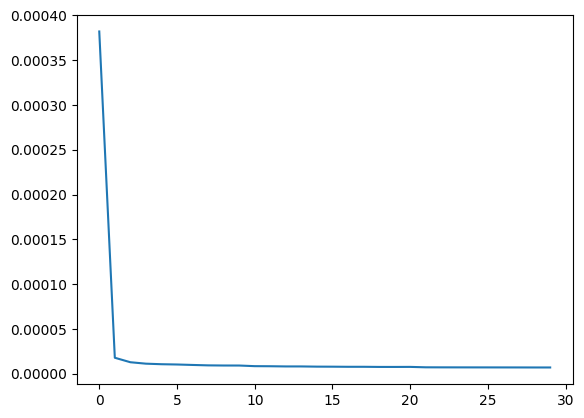

In [23]:
plt.plot(training_loss)

In [17]:
manager = WeightManager(artifact_path.joinpath("vdsr.pth").as_posix())

In [18]:
model_path = manager.get_filename()
model_path

WindowsPath('../../artifacts/vdsr/vdsr.pth')

In [27]:
manager.save_weight(model.state_dict(), model_path)

Save weight to ..\..\artifacts\vdsr\vdsr.pth, model size is 2.55MiB


In [19]:
manager.load_weight(model_path, model)

# Eval

In [20]:
# test_data_path = Path("../../data/VOCdevkit/VOC2012/JPEGImages/*")
test_data_path = Path("../../data/srcnn/Test/Set14/*.bmp")

In [21]:
test_preprocess = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

In [22]:
test_dataset = ImageDataset(
    test_data_path.as_posix(),
    transform=test_preprocess,
)

In [23]:
print(test_dataset[0].shape)

torch.Size([3, 480, 500])


In [24]:
def val_collate_fn(batch):
    xs, ys = [], []
    for x in batch:
        x = x.unsqueeze(0)
        
        if x.size(1) == 1:
            x = x.repeat(1, 3, 1, 1)
        
        # rgb -> ycbcr
        x = ycbcr_transform(x)
        
        x = x[:, 0:1]
        
        # mod crop
        h, w = x.shape[-2:]
        x = VF.crop(x, 0, 0, h - h % SCALE_FACTOR, w - w % SCALE_FACTOR)
        h, w = x.shape[-2:]
        
        # degradation
        y = F.interpolate(x, size=(h // SCALE_FACTOR, w // SCALE_FACTOR), mode="bicubic")
        y = F.interpolate(y, size=(h, w), mode="bicubic")
        
        xs.append(y)
        ys.append(x)

    return torch.cat(xs), torch.cat(ys)

In [25]:
val_loader = DataLoader(
    test_dataset,
    batch_size=1,
    collate_fn=val_collate_fn,
    pin_memory=True,
)

In [26]:
for x, y in tqdm(val_loader):
    print(x.shape, y.shape)
    break
    # pass

  0%|          | 0/14 [00:00<?, ?it/s]

torch.Size([1, 1, 480, 500]) torch.Size([1, 1, 480, 500])


## PSNR

In [27]:
from torchmetrics.image import PeakSignalNoiseRatio
from torchlake.super_resolution.controller.evaluator_srcnn import SRCNNEvaluator

In [28]:
metric = PeakSignalNoiseRatio(data_range=255)

In [29]:
evaluator = SRCNNEvaluator(DEVICE)
evaluator.set_scale_factor(SCALE_FACTOR)

In [30]:
metric = evaluator.run(val_loader, model, metric)

  0%|          | 0/14 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 16.75it/s]


In [31]:
metric.compute()

tensor(28.4290)

In [32]:
metric = PeakSignalNoiseRatio(data_range=255)

In [33]:
evaluator = SRCNNEvaluator(DEVICE)
evaluator.set_scale_factor(SCALE_FACTOR)

In [34]:
metric = evaluator.run(val_loader, nn.Identity(), metric)

100%|██████████| 14/14 [00:00<00:00, 36.94it/s]


In [35]:
metric.compute()

tensor(28.0208)

## Inference

In [36]:
def test_collate_fn(batch):
    xs, ys = [], []
    for x in batch:
        x = x.unsqueeze(0)
        
        if x.size(1) == 1:
            x = x.repeat(1, 3, 1, 1)
        
        # rgb -> ycbcr
        x = ycbcr_transform(x)
        
        # mod crop
        h, w = x.shape[-2:]
        x = VF.crop(x, 0, 0, h - h % SCALE_FACTOR, w - w % SCALE_FACTOR)
        h, w = x.shape[-2:]
        
        # degradation
        # y = F.interpolate(x, size=(h // SCALE_FACTOR, w // SCALE_FACTOR), mode="bicubic")
        # y = F.interpolate(y, size=(h, w), mode="bicubic")
        y = F.interpolate(x[:, 0:1], size=(h // SCALE_FACTOR, w // SCALE_FACTOR), mode="bicubic")
        y = F.interpolate(y, size=(h, w), mode="bicubic")
        y = torch.cat((y, x[:, 1:3]), 1)
        
        xs.append(y)
        ys.append(x)

    return torch.cat(xs), torch.cat(ys)

In [37]:
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    collate_fn=test_collate_fn,
    pin_memory=True,
)

In [38]:
for x, y in tqdm(test_loader):
    print(x.shape, y.shape)
    break
    # pass

  0%|          | 0/14 [00:00<?, ?it/s]

torch.Size([1, 3, 480, 500]) torch.Size([1, 3, 480, 500])


In [39]:
model.eval()
with torch.inference_mode(True):
    # output = model(x.to(DEVICE))
    # output = output.detach().cpu()
    
    output = model(x[:, 0:1].to(DEVICE))
    output = output.detach().cpu()
    output = torch.cat((output, x[:, 1:3, :, :]), 1)

In [40]:
x.shape, output.shape

(torch.Size([1, 3, 480, 500]), torch.Size([1, 3, 480, 500]))

In [41]:
# claude code suggests identity check
(output - x).abs().mean(), (output - y).abs().mean(), (y - x).abs().mean()

(tensor(0.0050), tensor(0.0152), tensor(0.0158))

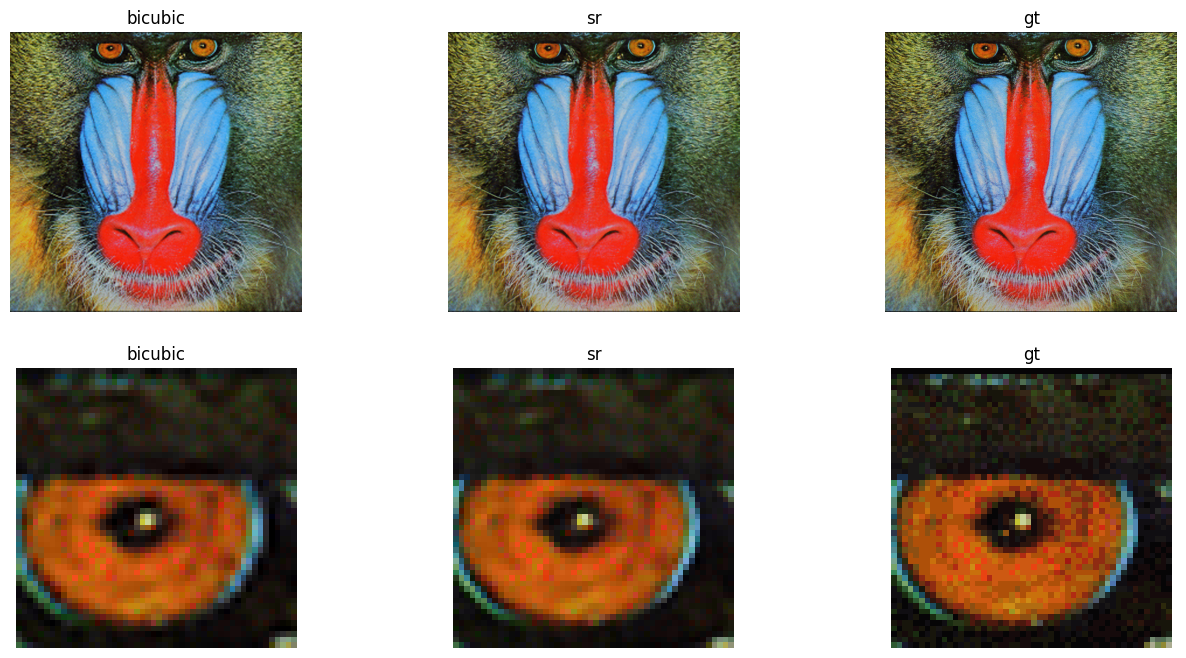

In [42]:
bicubic_img = img_tensor_to_np(ycbcr_inverse_transform(x).clamp(0, 1))
sr_img = img_tensor_to_np(ycbcr_inverse_transform(output).clamp(0, 1))
gt = img_tensor_to_np(ycbcr_inverse_transform(y).clamp(0, 1))

bicubic_patch = bicubic_img[0:50, 150:200]
sr_patch = sr_img[0:50, 150:200]
gt_patch = gt[0:50, 150:200]

plot_grids(
    (bicubic_img, sr_img, gt, bicubic_patch, sr_patch, gt_patch),
    ("bicubic", "sr", "gt") * 2,
    num_col=3,
    num_row=2,
    figsize=(16, 8)
)

In [50]:
# plot_grids(img_tensor_to_np(model.foot.block[0].weight[:, 0:1].detach().cpu()), num_col=8, num_row=8, is_gray_scale=True)